## <center> Prelims 2024
### <center> Mani Tyagi
#### <center> 200973108

In [11]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [3]:
# Define the system of differential equations
def system(t, variables, alpha):
    L, X, Y = variables
    dL_dt = -4 * alpha * X - 4800 * L
    dX_dt = -5 * L * (Y - 0.01) - 330 * X
    dY_dt = 5 * L * X - 330 * (Y - 0.1)
    return [dL_dt, dX_dt, dY_dt]

### Part (a)

In [20]:
# Set the initial conditions
initial_conditions = [0.01, 0.01, 0.1]

# Set the parameter alpha
alpha = 0.1

# Set the time points for which to solve the system
t_span = [0, 1]

# Solve the system of IVPs using solve_ivp
solution = solve_ivp(system, t_span, initial_conditions, args=(alpha,), method='RK45')

# Print the solution
# Print the time points and the corresponding values of the dependent variables
print("Time Points (t):\n", solution.t)
print("\nDependent Variables (L, X, Y):")
for i, variable in enumerate(['\nL: ', '\nX: ', '\nY: ']):
    print(f"{variable} {solution.y[i]}")


Time Points (t):
 [0.00000000e+00 1.96184384e-04 3.92368769e-04 ... 9.98838744e-01
 9.99602312e-01 1.00000000e+00]

Dependent Variables (L, X, Y):

L:  [1.00000000e-02 3.90231334e-03 1.52253717e-03 ... 7.94883146e-07
 1.50476577e-06 2.65459683e-07]

X:  [1.00000000e-02 9.37255271e-03 8.78477568e-03 ... 8.00217925e-11
 1.51486485e-10 2.67241289e-11]

Y:  [0.1        0.10000006 0.10000008 ... 0.1        0.1        0.1       ]


### Part (b)

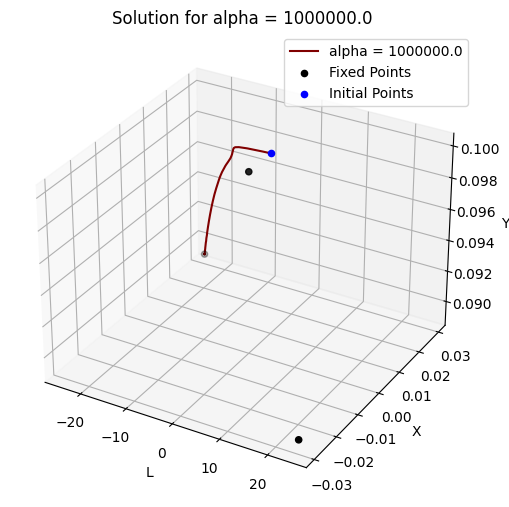

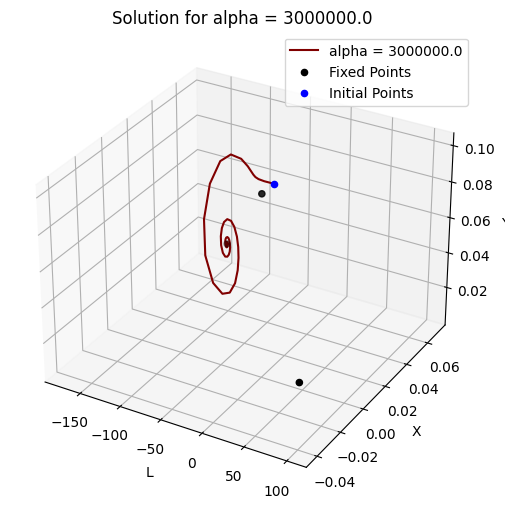

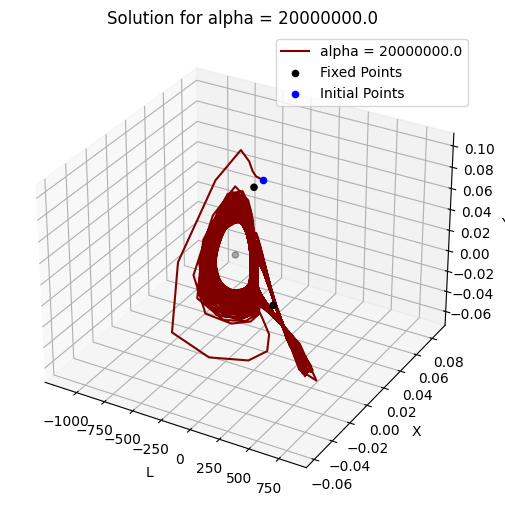

In [38]:
# Set the initial conditions
initial_conditions = [0.01, 0.01, 0.1]

# Set the values of alpha
alpha_values = [1e6, 3e6, 2e7]

# Set the time points for which to solve the system
t_span = [0, 1]

# Loop over alpha values
for alpha in alpha_values:
    # Solve the system of IVPs using solve_ivp
    solution = solve_ivp(system, t_span, initial_conditions, args=(alpha,), method='RK45')

    # Create a new figure for each alpha value
    fig = plt.figure(figsize=(6, 10))
    ax = fig.add_subplot(111, projection='3d')

    # three fixed points
    L1 = 0
    X1 = 0
    Y1 = 0.1
    
    L_tilde = 66 * np.sqrt((alpha/880000)-1)
    
    L2 = L_tilde 
    X2 = -(1200/alpha)*(L_tilde) 
    Y2 = 0.1 - (200/(11 * alpha))*(L_tilde**2) 
    
    L3 = -L_tilde 
    X3 = (1200/alpha)*(L_tilde) 
    Y3 = 0.1 - (200/(11 * alpha))*(L_tilde**2) 
    
    # Plot the solution in three-dimensional space
    ax.plot(solution.y[0], solution.y[1], solution.y[2], label=f'alpha = {alpha}', color='maroon')
    ax.set_xlabel('L')
    ax.set_ylabel('X')
    ax.set_zlabel('Y')
    ax.set_title(f'Solution for alpha = {alpha}')
    ax.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.2)
    ax.scatter([L1, L2, L3], [X1, X2, X3], [Y1, Y2, Y3], color='black', marker='o', label='Fixed Points')
    
    # Scatter plot for initial points
    ax.scatter(initial_conditions[0], initial_conditions[1], initial_conditions[2], color='blue', marker='o', label='Initial Points')
    
    # Add legend
    ax.legend()

    # Show plot
    plt.show()


### part (c)

The Jacobian matrix \( J \) is given by:
\[
J =
\begin{bmatrix}
\frac{\partial f_1}{\partial L} & \frac{\partial f_1}{\partial X} & \frac{\partial f_1}{\partial Y} \\
\frac{\partial f_2}{\partial L} & \frac{\partial f_2}{\partial X} & \frac{\partial f_2}{\partial Y} \\
\frac{\partial f_3}{\partial L} & \frac{\partial f_3}{\partial X} & \frac{\partial f_3}{\partial Y}
\end{bmatrix}
\]

Calculating the partial derivatives:
\begin{align*}
\frac{\partial f_1}{\partial L} = -4800,  \quad \quad 
\frac{\partial f_1}{\partial X} = -4\alpha,  \quad \quad
\frac{\partial f_1}{\partial Y} = 0 \\
\\
\frac{\partial f_2}{\partial L} = -5(Y - 0.01), \quad
\frac{\partial f_2}{\partial X} = -330, \quad
\frac{\partial f_2}{\partial Y} = -5L \\
\\
\frac{\partial f_3}{\partial L} = 5X, \quad \quad
\frac{\partial f_3}{\partial X} = 5L, \quad 
\frac{\partial f_3}{\partial Y} = -330 \\
\end{align*}
<br>
Hence, the Jacobian matrix is
$$
J =\begin{bmatrix}
-4800 & -4\alpha & 0 \\
-5(Y - 0.01) & -330 & -5L \\
5X & 5L & -330
\end{bmatrix}
$$

### Part (d)

In [44]:
# Define the Jacobian matrix
def jacobian(L, X, Y, alpha):
    J = np.array([
        [-4800, -4*alpha, 0],
        [-5*(Y - 0.01), -330, -5*L],
        [5*X, 5*L, -330]
    ])
    return J

# Fixed points
fixed_points = [(L1, X1, Y1), (L2, X2, Y2), (L3, X3, Y3)]

# Values of alpha
alpha_values = [1e6, 3e6, 2e7]

# Loop over alpha values
for alpha in alpha_values:
    print("********************************************")
    print(f"For alpha = {alpha}:")
    print("********************************************")
    
    for i, point in enumerate(fixed_points):
        L, X, Y = point
        # Compute the Jacobian matrix
        J = jacobian(L, X, Y, alpha)
        # Compute eigenvalues
        eigenvalues = np.linalg.eigvals(J)
        print(f"Eigenvalues at fixed point {i+1}: {eigenvalues} \n")


********************************************
For alpha = 1000000.0:
********************************************
Eigenvalues at fixed point 1: [-5171.76523684    41.76523684  -330.        ] 

Eigenvalues at fixed point 2: [-4840.73095985   +0.j          -309.63452008+1571.69069758j
  -309.63452008-1571.69069758j] 

Eigenvalues at fixed point 3: [-4840.73095985   +0.j          -309.63452008+1571.69069758j
  -309.63452008-1571.69069758j] 

********************************************
For alpha = 3000000.0:
********************************************
Eigenvalues at fixed point 1: [-5789.162682   659.162682  -330.      ] 

Eigenvalues at fixed point 2: [-4919.2619591    +0.j         -270.36902045+1634.7074718j
  -270.36902045-1634.7074718j] 

Eigenvalues at fixed point 3: [-4919.2619591    +0.j         -270.36902045+1634.7074718j
  -270.36902045-1634.7074718j] 

********************************************
For alpha = 20000000.0:
********************************************
Eigenvalues at